# Nested sampling

In [2]:
#!pip install dynesty

In [152]:
import os
import numpy as np
import matplotlib.pyplot as plt

import pickle
from dynesty import utils as dyfunc

In [153]:
from nested_sampling import MixtureNestedSampler
from gen_synth_data import gen_synth_data
from ns_plots import cornerplot_ns, plot_distribution_ns

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [154]:
import dynesty
print("dynesty version:", dynesty.__version__)

dynesty version: 3.0.0


In [155]:
FONTSIZE=16
LABELSIZE=0.9*FONTSIZE
LINEWIDTH=2.0
FIGWIDTH=8
ASPECT_RATIO=4/3

plt.rcParams['axes.labelsize'] = FONTSIZE
plt.rcParams['axes.linewidth'] = LINEWIDTH
plt.rcParams['axes.titlesize'] = 1.1*FONTSIZE
plt.rcParams['figure.figsize'] = [FIGWIDTH, FIGWIDTH/ASPECT_RATIO]
plt.rcParams['figure.labelsize'] = FONTSIZE
plt.rcParams['figure.titlesize'] = 1.1*FONTSIZE
plt.rcParams['legend.fancybox'] = False
plt.rcParams['legend.framealpha'] = 1.0
plt.rcParams['legend.fontsize'] = LABELSIZE
plt.rcParams['legend.title_fontsize'] = LABELSIZE
plt.rcParams['patch.linewidth'] = LINEWIDTH
plt.rcParams['lines.linewidth'] = LINEWIDTH
plt.rcParams['xtick.labelsize'] = LABELSIZE
plt.rcParams['ytick.labelsize'] = LABELSIZE
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['figure.autolayout'] = True

plt.rcParams['patch.edgecolor'] = 'black'

In [156]:
DATA_PATH = "../GRBs/GRB_data.txt"
arr = np.loadtxt(DATA_PATH, skiprows=1)
logT90 = arr[:,0]
sigma_logT90 = arr[:,1]

## Real data

### Single run - real data

In [16]:
%%time
# -------------------------
# RUN DYNESTY (H0 and H1)
# -------------------------
# settings
nlive = 1200 #600          # aumenta se vuoi più accuratezza
dlogz = 0.01  #0.5          # stopping criterion; più piccolo = più preciso (ma più lento)
print_progress = True
bound  = 'multi'
sample = 'unif'
rng = np.random.default_rng(1234)

# H0 run
print("Running dynesty for H0 (2 components)...")

#sampler0 = DynamicNestedSampler(loglik_h0, prior_transform_h0, ndim=5,
#                                bound='multi', sample='rwalk', rstate=rng)
#sampler0.run_nested(dlogz_init=dlogz, print_progress=print_progress, nlive_init=nlive)

sampler0 = NestedSampler(loglik_h0, prior_transform_h0, ndim=5, nlive=nlive,
                         bound=bound, sample=sample, bootstrap=False, rstate=rng)
sampler0.run_nested(dlogz=dlogz, print_progress=print_progress)
res0 = sampler0.results
logZ0 = res0.logz[-1]
logZerr0 = res0.logzerr[-1]
print("H0 done: logZ = {:.3f} +- {:.3f}".format(logZ0, logZerr0))

# H1 run
print("Running dynesty for H1 (3 components)...")

#sampler1 = DynamicNestedSampler(loglik_h1, prior_transform_h1, ndim=8, 
#                                bound='multi', sample='rwalk', rstate=rng)
#sampler1.run_nested(dlogz_init=dlogz, print_progress=print_progress, nlive_init=nlive)

sampler1 = NestedSampler(loglik_h1, prior_transform_h1, ndim=8, nlive=nlive,
                         bound=bound, sample=sample, bootstrap=False, rstate=rng)
sampler1.run_nested(dlogz=dlogz, print_progress=print_progress)

res1 = sampler1.results
logZ1 = res1.logz[-1]
logZerr1 = res1.logzerr[-1]
print("H1 done: logZ = {:.3f} +- {:.3f}".format(logZ1, logZerr1))

# BAYES FACTOR e probabilità a posteriori (prior model equiprobabili)
logBF = logZ1 - logZ0
# propaga errore approssimativamente
logBF_err = np.sqrt(logZerr0**2 + logZerr1**2)
post_prob_H1 = 1.0 / (1.0 + np.exp(-logBF))

print("logBF (H1 vs H0) = {:.3f} +- {:.3f}".format(logBF, logBF_err))
print("P(H1|D) (equiprob. apriori) = {:.4f}".format(post_prob_H1))

"""
# Salva risultati/res
with open('../chains/dynesty_results_H0.pkl', 'wb') as f:
    pickle.dump(res0, f)
with open('../chains/dynesty_results_H1.pkl', 'wb') as f:
    pickle.dump(res1, f)

print("Risultati salvati in dynesty_results_H0.pkl e dynesty_results_H1.pkl")
"""

Running dynesty for H0 (2 components)...


29778it [01:59, 250.14it/s, +1200 | bound: 73 | nc: 1 | ncall: 131068 | eff(%): 23.853 | loglstar:   -inf < -3875.744 <    inf | logz: -3895.940 +/-  0.122 | dlogz:  0.000 >  0.010]


H0 done: logZ = -3895.940 +- 0.125
Running dynesty for H1 (3 components)...


38433it [1:11:54,  8.91it/s, +1200 | bound: 1797 | nc: 1 | ncall: 4215270 | eff(%):  0.940 | loglstar:   -inf < -3869.918 <    inf | logz: -3897.328 +/-  0.134 | dlogz:  0.000 >  0.010]


H1 done: logZ = -3897.328 +- 0.138
logBF (H1 vs H0) = -1.387 +- 0.186
P(H1|D) (equiprob. apriori) = 0.1998
CPU times: user 1h 33min 4s, sys: 4min 46s, total: 1h 37min 51s
Wall time: 1h 13min 56s


'\n# Salva risultati/res\nwith open(\'../chains/dynesty_results_H0.pkl\', \'wb\') as f:\n    pickle.dump(res0, f)\nwith open(\'../chains/dynesty_results_H1.pkl\', \'wb\') as f:\n    pickle.dump(res1, f)\n\nprint("Risultati salvati in dynesty_results_H0.pkl e dynesty_results_H1.pkl")\n'

#### Dinamic Nested Sampling

Risultati con 600 live points e dlogz=0.5:

    H0 done: logZ = -3896.268 +- 0.114
    H1 done: logZ = -3896.849 +- 0.126
    logBF (H1 vs H0) = -0.581 +- 0.170
    P(H1|D) (equiprob. apriori) = 0.3586

Risultati con 1200 live points e dloz=0.1: (21 min)

    H0 done: logZ = -3896.098 +- 0.136
    H1 done: logZ = -3897.439 +- 0.150
    logBF (H1 vs H0) = -1.341 +- 0.203
    P(H1|D) (equiprob. apriori) = 0.2074

Risultati con 5000 live points e dlogz=0.1: (1h 6min 10s)

    H0 done: logZ = -3896.108 +- 0.079
    H1 done: logZ = -3897.005 +- 0.082
    logBF (H1 vs H0) = -0.897 +- 0.114
    P(H1|D) (equiprob. apriori) = 0.2897

Risultati con 1200 live points e dlogz=0.01: (15min 44s)

    H0 done: logZ = -3896.027 +- 0.106
    H1 done: logZ = -3897.289 +- 0.125
    logBF (H1 vs H0) = -1.262 +- 0.164
    P(H1|D) (equiprob. apriori) = 0.2207

Risultati con 1200 live points e dlogz=0.001:  

    H0 done: logZ = -3896.043 +- 0.102
    H1 done: logZ = -3896.846 +- 0.120
    logBF (H1 vs H0) = -0.803 +- 0.157
    P(H1|D) (equiprob. apriori) = 0.3095

#### Static Nested Sampling

Risultati con 1200 live points e dlogz=0.01: (15min 50s)

    H0 done: logZ = -3896.065 +- 0.126
    H1 done: logZ = -3897.183 +- 0.137
    logBF (H1 vs H0) = -1.118 +- 0.186
    P(H1|D) (equiprob. apriori) = 0.2463

#### Decision boundary (sample = 'rwalk')
Risultati con 1200 live points e dlogz=0.01 con parametri delta e bound='multi': (15min 11s)

    H0 done: logZ = -3896.065 +- 0.126
    H1 done: logZ = -3897.609 +- 0.138
    logBF (H1 vs H0) = -1.544 +- 0.187
    P(H1|D) (equiprob. apriori) = 0.1759

Risultati con 1200 live points e dlogz=0.01 con parametri delta e bound='single': (14min 22s)

    H0 done: logZ = -3896.015 +- 0.126
    H1 done: logZ = -3897.870 +- 0.138
    logBF (H1 vs H0) = -1.855 +- 0.187
    P(H1|D) (equiprob. apriori) = 0.1353

Risultati con 1200 live points e dlogz=0.01 con parametri delta e bound='none': (13min 43s)

    H0 done: logZ = -3895.762 +- 0.125
    H1 done: logZ = -3897.460 +- 0.135
    logBF (H1 vs H0) = -1.698 +- 0.184
    P(H1|D) (equiprob. apriori) = 0.1547

- _bound = 'none'_: semplice  __rejection sampling__, diventa meno efficente all'aumentare del valore L_min (constraint sulla prior mass), questo perché lo spazio dei parametri che viene accettato diventa sempre più piccolo all'aumentare del valore minimo di L.
- _bound = 'single'_: viene creata un ellissi utilizzando la media e la covarianza empirica dei live points; successivamente viene moltiplicata per un fattore (calcolato con boostrap se sample='uniform'; altrimenti il valore di default è 1.25) per contenere anche i life points rimasti fuori dall'ellissi.
- _bound = 'multi'_:
 
  - parte da un ellissi come nel caso precedente;
  - seleziona i due punti corrispondenti agli estremi opposti dell'asse maggiore dell'ellisse;
  - applica k-means utilizzando que due punti (k=2) ed assegna i punti ai due clusters
  - costruisce un ellisse per ogni cluster
  - se la diminuzione in volume supera una certa soglia, riparte dal punto 2 e divide ulteriormente i cluster; altrimenti si ferma
  
I valori sono tutti compatibili al variare di bound, quindi viene scelta la scelta più semplice ed efficente _bound='none'_, probabilmente il tempo di computazione impiegato per creare gli ellissi compensa il tempo guadagnoto nel rigettare meno punti.

#### Decision boundary (sample = 'unif')
Risultati con 1200 live points e dlogz=0.01 con parametri delta, bound='multi' e sample='unif': (1h 37min 51s)

    H0 done: logZ = -3895.940 +- 0.125
    H1 done: logZ = -3897.328 +- 0.138
    logBF (H1 vs H0) = -1.387 +- 0.186
    P(H1|D) (equiprob. apriori) = 0.1998

Con _sample='unif'_ il valore di scala per aumentare il volume dell'ellisse e calcolato con bootstap risulta troppo grande (segnale di warning dal codice), quindi è stato fissato _bootstrap=False_ con conseguente fattore di scala bloccato a 1.25.

#### Sample rwalk

Anche se nel paper sono indicati due tipi di random walk ('fixed' e 'varible' proposal), il secondo è stato eliminato e il primo è stato modificato. il sampler _rwalk_ ha una proposal variabile, ma con frequenza bassa (cioè cambia raramente all'interno di una catena). Le modifiche alla proposal sono due:

1) La proposal consiste in un ellissi centrata nel punto da modificare e con la stessa grandezza della decision boundary. Nel caso di decision boundary unitaria allora calcolo l'ellisse con covarianza e media empirica di tutti i live points; invece nel caso di bound multi prendo casualmente un'ellisse che interseca il punto da modificare. L'update della decision bundary viene scelto con l'iperprametro _update_interval_, nel caso di sampling _rwalk_ corrisponde a round(0.15*nlive*walk)=4500 dove nlive è il numero di live points (1200) e walk è il numero di passi ad ogni iterazione (25). Si ottiene 0.15*1200*25 = 4500 chiamate di likelihood, cioè ogni volta che viene calcolata la likelihood il contatore incrementa; essendoci 25 passi per ogni iterazione si ha che 4500/25=180 è il numero di iterazioni prima che le decision boundary vengono aggiornate.
Per estrarre un punto uniformemente da un'ellisse devo:
   - generare un punto da una distribuzione normale: $Z = (Z1, ... , Zd)$ con $Z_i \sim \mathcal{N}(0,1)$
   - prendo la direzione del punto $V = Z/||Z||$ (punto uniforme su una superficie sferica)
   - estraggo $U \sim$ Uniform(0,1), calcolo il raggio $r=U^{1/d}$ e inserisci la direzione $S=rV$, questo trasforma il punto dalla superficie ad un punto interno alla sfera (punto uniforme nella sfera). L'esponenziale 1/d permette di avere il volume uniforme in una sfera d-dimensionale
   - Trasforma la sfera in un ellissi utilizzando la covarianza del decision boundary $C_b$ centrata sul live point da eliminare $\theta_b$:  $\theta = \theta_b + C_b^{1/2}S$, dove $C_b^{1/2} = L$ con $LL^\dagger=C_b$

2) Oltre alla forma della proposal viene modificata la scala in base al ratio di accettazione, il quale viene aggiornato ad ogni iterazione (non ad ogni passo della catena, ma di default ogni 25 passi). la formula per l'update è:
   $s_{i+1} = s_i \times \rm{exp}\frac{\rm{ratio} - \rm{target}}{d \times \rm{target}}$
dove s è la scala da moltiplicare per $C_b^{1/2}S$ del punto precedente, ratio è il ratio di accettazione di una sola iterazione (cioè su 25 passi della catena), target è il rapporto di accetazione atteso (di default 0.5) e d è la dimensione dei parametri. Se preso il logaritmo diventa simile ad un gradient discend: $log(s_{i+1}) = log(s_i) + \eta (\rm{ratio} - \rm{target})$ dove $\eta=1/(d \times \rm{target})$ è un passo fisso. Imporre $\eta \sim 1/d$ è probabilmente per avere un update più conservativo nel caso di problemi ad alta dimensione, dove è facile uscire fuori dalla postirior (volume prior >> volume postirior per d grande).

    - ratio > target: vuol dire che sto accettando troppo, quindi la proposal è troppo piccola -> $s_{i+1} > s_i$
    - ratio < target: vuol dire che sto rifiutando troppo, quindi la proposal è troppo grande -> $s_{i+1} < s_i$
   

### Multi runs - real data

In [159]:
%%time
LOAD = True
bound_name = ''#'_bound_none'
fn0 = f'../chains/dynesty_multirun_H0_static{bound_name}.pkl'
fn1 = f'../chains/dynesty_multirun_H1_static{bound_name}.pkl'

ns = MixtureNestedSampler(logT90, sigma_logT90)
if LOAD == 0:
    # ---------- ESECUZIONE: multirun H0 e H1, poi PPC ----------
    n_runs = 3
    nlive = 100
    dlogz = 0.5
    seed = 1234

    rng = np.random.default_rng(seed)
    res_list_H0, logZs_H0 = ns.multirun_model('H0', n_runs=n_runs, nlive=nlive, dlogz=dlogz, rng=rng)
    
    rng = np.random.default_rng(seed) #resetto il generatore per usare stessi valori di H0
    res_list_H1, logZs_H1 = ns.multirun_model('H1', n_runs=n_runs, nlive=nlive, dlogz=dlogz, rng=rng)
    
    with open(fn0, 'wb') as f:
        pickle.dump({'results': res_list_H0, 'logZs': logZs_H0}, f)
    with open(fn1, 'wb') as f:
        pickle.dump({'results': res_list_H1, 'logZs': logZs_H1}, f)
    print("Risultati multirun salvati in ../chains/")
       
else:
    with open(fn0, 'rb') as f:
        d0 = pickle.load(f)
    with open(fn1, 'rb') as f:
        d1 = pickle.load(f)
    
    res_list_H0, logZs_H0 = d0['results'], np.array(d0['logZs'])
    res_list_H1, logZs_H1 = d1['results'], np.array(d1['logZs'])

CPU times: user 94.7 ms, sys: 43.1 ms, total: 138 ms
Wall time: 137 ms


In [160]:
# Z0, Z1 arrays; res_list_H0/1 are dynesty results lists
Z0 = np.array(logZs_H0)   # dimension n
Z1 = np.array(logZs_H1)
n = len(Z0)

# internal variances (sigma^2) from dynesty logzerr
err0 = np.array([float(r.logzerr[-1]) for r in res_list_H0])
err1 = np.array([float(r.logzerr[-1]) for r in res_list_H1])
mean_internal_var0 = np.mean(err0**2)
mean_internal_var1 = np.mean(err1**2)

# between-run sample variance (ddof=1)
var_between0 = np.var(Z0, ddof=1)
var_between1 = np.var(Z1, ddof=1)

# SE on the means
se_mean_Z0 = np.sqrt((var_between0 + mean_internal_var0) / n)
se_mean_Z1 = np.sqrt((var_between1 + mean_internal_var1) / n)

print("Z0 mean = {:.4f} ± {:.4f} (SE)".format(Z0.mean(), se_mean_Z0))
print("Z1 mean = {:.4f} ± {:.4f} (SE)".format(Z1.mean(), se_mean_Z1))

# paired diffs
diffs = Z1 - Z0                 # d_i
var_between_d = np.var(diffs, ddof=1)
# internal variance per differenza = err1^2 + err0^2
mean_internal_var_d = np.mean(err1**2 + err0**2)
se_mean_diff = np.sqrt((var_between_d + mean_internal_var_d) / n)

mean_diff = diffs.mean()
print("mean logBF (paired) = {:.4f} ± {:.4f} (SE)".format(mean_diff, se_mean_diff))

post_prob_H1 = 1.0 / (1.0 + np.exp(-mean_diff))

print(f"P(H1|D) = {post_prob_H1:.4f}")

#ppc_and_plots(res_list_H0[0], res_list_H1[0], n_ppc_samples=300, outdir='../figures')

Z0 mean = -3896.0102 ± 0.0604 (SE)
Z1 mean = -3897.7560 ± 0.1144 (SE)
mean logBF (paired) = -1.7458 ± 0.1199 (SE)
P(H1|D) = 0.1486


#### Dinamic nested sampling
Risultati nlive=1200, dloz=0.01, n_runs=5:

    Z0 mean = -3896.0326 ± 0.1090 (SE)
    Z1 mean = -3896.5196 ± 0.1986 (SE)
    mean logBF (paired) = -0.4871 ± 0.2131 (SE)
    P(H1|D) = 0.3806

#### Static nested sampling
Risultati nlive=1200, dloz=0.01, n_runs=5, bound='multi': (53 min only H1)

    Z0 mean = -3896.0102 ± 0.0604 (SE)
    Z1 mean = -3897.7560 ± 0.1144 (SE)
    mean logBF (paired) = -1.7458 ± 0.1199 (SE)
    P(H1|D) = 0.1486

Risultati nlive=1200, dloz=0.01, n_runs=5, bound='none': (1h 27min 48s)

    Z0 mean = -3896.0538 ± 0.1595 (SE)
    Z1 mean = -3897.3949 ± 0.1186 (SE)
    mean logBF (paired) = -1.3411 ± 0.2559 (SE)
    P(H1|D) = 0.2073

In [161]:
# Errore sul calcolo delle Z vs errore sulla variazione dei seed
# H0
print(np.sqrt(mean_internal_var0))
print(np.sqrt(var_between0))
print(se_mean_Z0*np.sqrt(n)) #combinazione dei due errori (supponendo indipendenza)

# H1
print('\n')
print(np.sqrt(mean_internal_var1))
print(np.sqrt(var_between1))
print(se_mean_Z1*np.sqrt(n))

# BF
print('\n')
print(np.sqrt(var_between_d))
print(np.sqrt(mean_internal_var_d))
print(se_mean_diff*np.sqrt(n))

0.12552053429471907
0.049805877999576836
0.1350408457206207


0.13816729446311873
0.2152381743995614
0.2557687881234029


0.19241343127122565
0.18666977738479762
0.268083073547094


In [162]:
# Merge into a single run.
res_merged_H0 = dyfunc.merge_runs(res_list_H0)
res_merged_H1 = dyfunc.merge_runs(res_list_H1)

Merge: 5/5     

In [163]:
print(res_list_H0[0]['samples'].shape)
print(res_list_H1[0]['samples'].shape)

print('\n')
print(res_merged_H0['samples'].shape)
print(res_merged_H1['samples'].shape)

(31135, 5)
(40610, 8)


(155343, 5)
(200924, 8)


La funzione _merge_runs_ mette insieme le run dell'ensemble in modo da aumentare il numero di sample pesati disponibili. Ad ogni iterazione viene preso un sample $\theta_i$ il quale viene pesato con l'area del rettangolo $w_i = \Delta X_i L^{(min)}_i$, dove X è la prior mass, $L^{(min)}_i = L(\theta_i)$ e l'indice _i_ indica l'iterazione. Se vogliamo la posterior su quel sample bisogna normalizzare con la somma di tutte le aree, che corrisponde all'evidenza Z: 

$P(\theta_i) = \frac{\Delta X_i L^{(min)}_i}{Z}$

Una volta ottenuti i pesi $w_i$ dei vari sample $\theta_i$ è possibile fare __importance sampling__, cioè estrarre con replacement un certo numero di sample utilizzando i pesi $w_i$ (rng.choice(len(w), size=n_samples, replace=True, p=w))

In [164]:
logZ0 = res_merged_H0.logz[-1]
logZerr0 = res_merged_H0.logzerr[-1]
print("H0 done: logZ = {:.3f} +- {:.3f}".format(logZ0, logZerr0))

logZ1 = res_merged_H1.logz[-1]
logZerr1 = res_merged_H1.logzerr[-1]
print("H1 done: logZ = {:.3f} +- {:.3f}".format(logZ1, logZerr1))

# BAYES FACTOR e probabilità a posteriori (prior model equiprobabili)
logBF = logZ1 - logZ0
# propaga errore approssimativamente
logBF_err = np.sqrt(logZerr0**2 + logZerr1**2)
post_prob_H1 = 1.0 / (1.0 + np.exp(-logBF))

print("logBF (H1 vs H0) = {:.3f} +- {:.3f}".format(logBF, logBF_err))
print("P(H1|D) (equiprob. apriori) = {:.4f}".format(post_prob_H1))

H0 done: logZ = -3896.016 +- 0.057
H1 done: logZ = -3897.773 +- 0.061
logBF (H1 vs H0) = -1.757 +- 0.084
P(H1|D) (equiprob. apriori) = 0.1472


Risultati MERGED nlive=1200, dloz=0.01, n_runs=5, bound='multi': 

    H0 done: logZ = -3896.016 +- 0.057
    H1 done: logZ = -3897.773 +- 0.061
    logBF (H1 vs H0) = -1.757 +- 0.084
    P(H1|D) (equiprob. apriori) = 0.1472

Risultati MERGED nlive=1200, dloz=0.01, n_runs=5, bound='none': 

    H0 done: logZ = -3896.060 +- 0.057
    H1 done: logZ = -3897.414 +- 0.062
    logBF (H1 vs H0) = -1.354 +- 0.084
    P(H1|D) (equiprob. apriori) = 0.2052

In questi risultati l'__errore è sottostimato__ perché non sta tenendo condo della variabilità dovuta alla randomicità della posizione dei live points, cosa che veniva contat nell'ensemble precedente.

In [166]:
# Carico i risultati del MCMC per confrontarli con quelli del nested sampling
samples = np.loadtxt('../chains/chain_final.txt')
params_mcmc = np.mean(samples,axis=0)
samples.shape

(4349, 5)

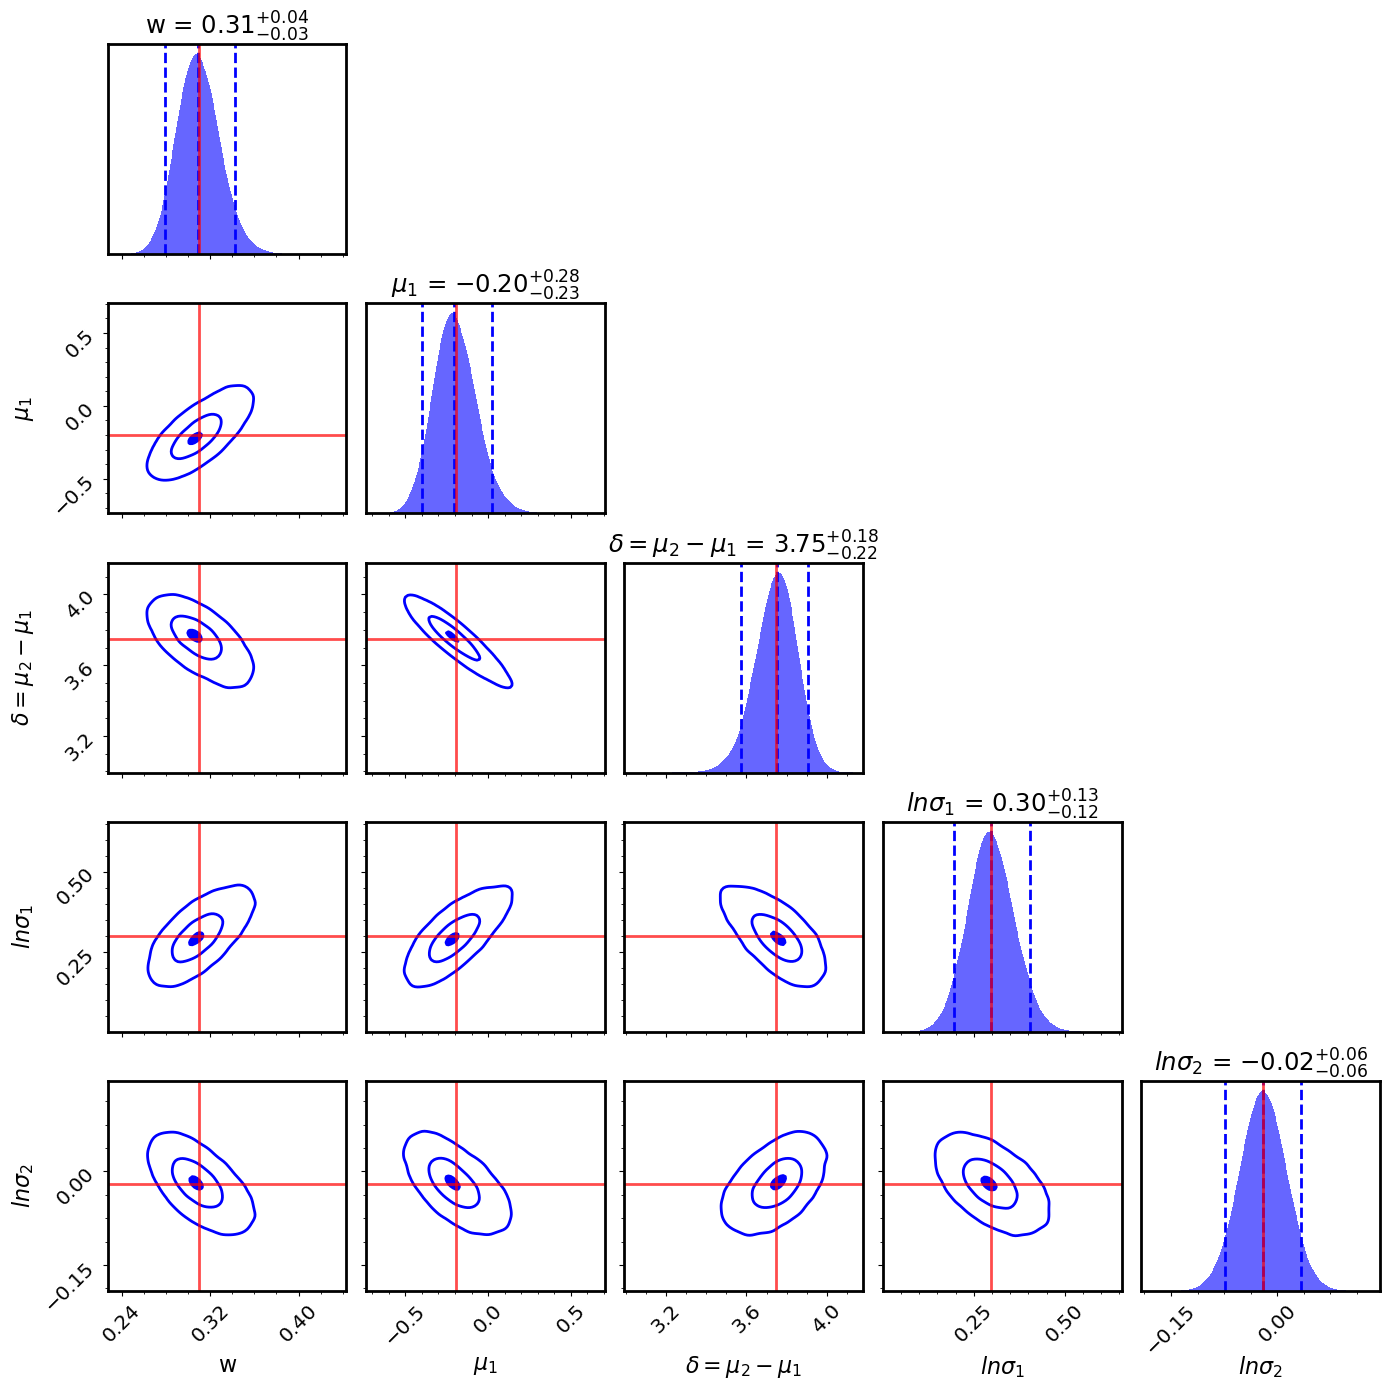

In [167]:
model     = 'H0'
filename  = f'cornerplot_ns_{model}_multi'
fig, axes = cornerplot_ns(res_merged_H0, filename, truths=params_mcmc, model=model, save=True)

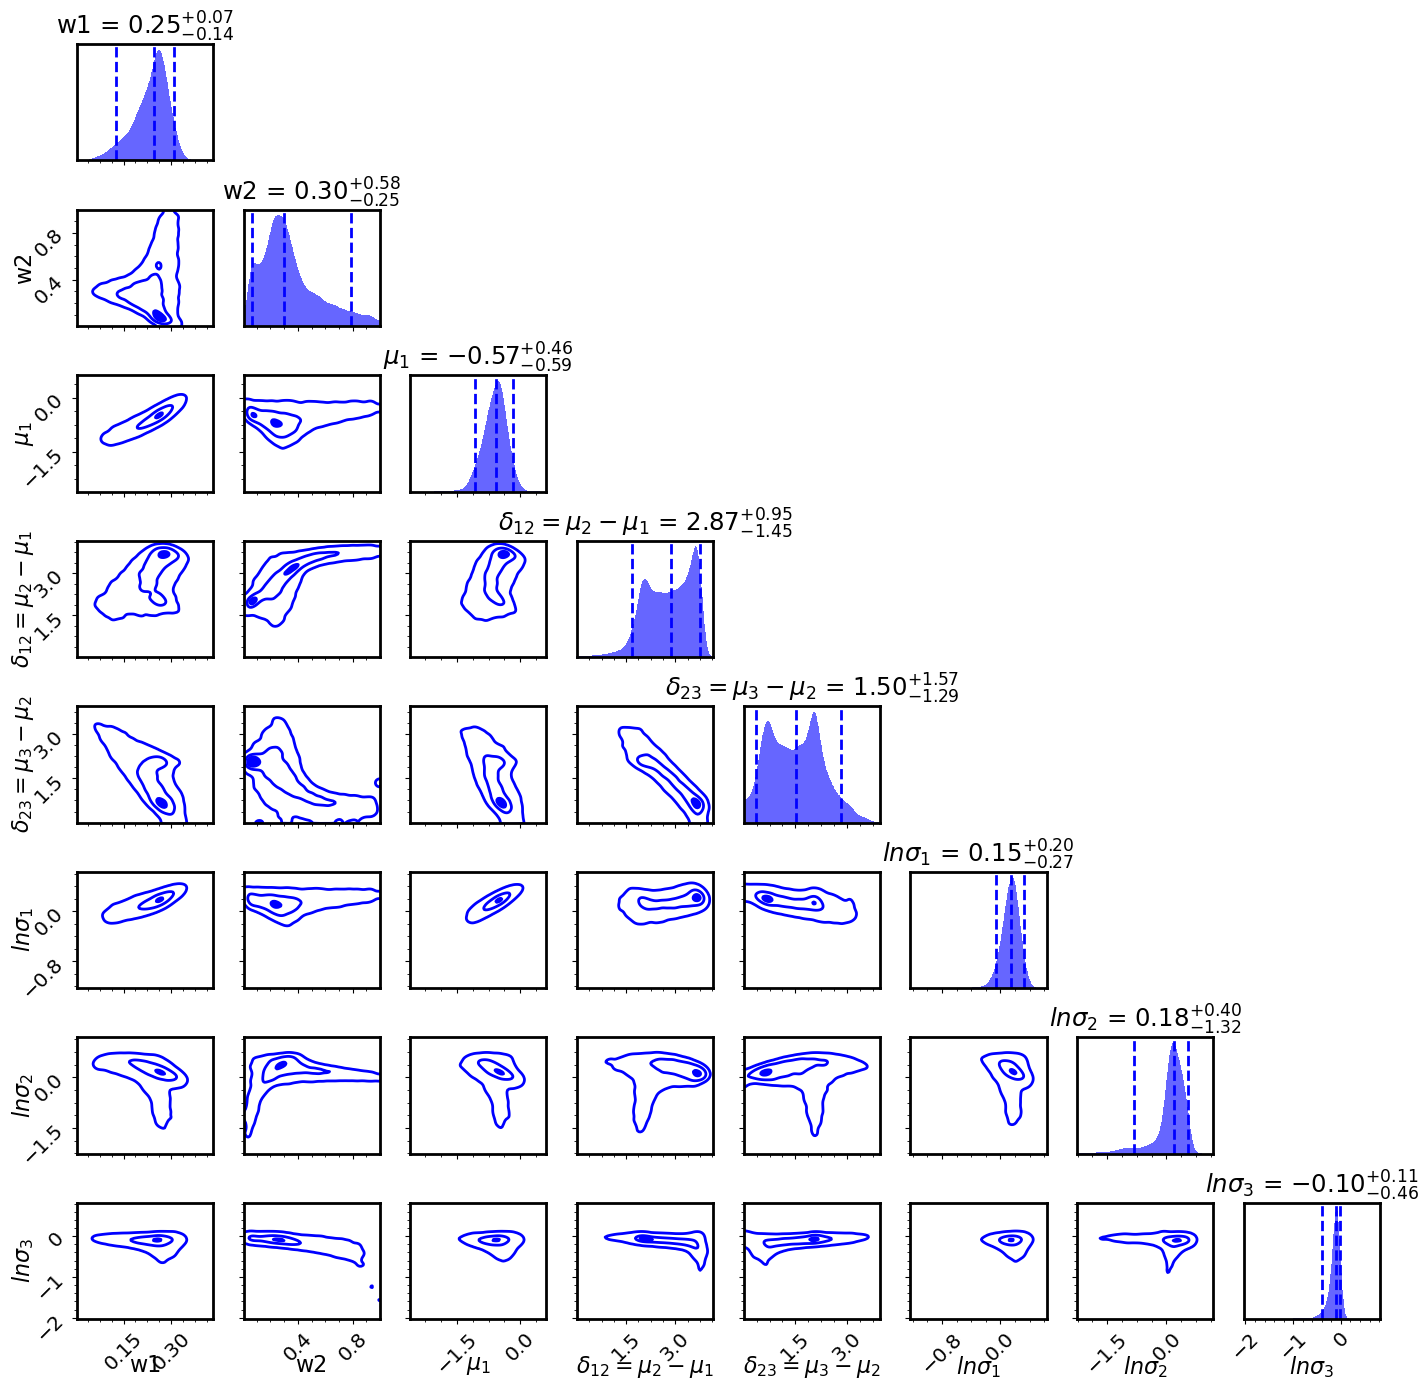

In [168]:
model     = 'H1'
filename  = f'cornerplot_ns_{model}_multi'
fig, axes = cornerplot_ns(res_merged_H1, filename, truths=None, model=model, save=True)

In [169]:
rng = np.random.default_rng(1234)
post_samps_H0 = ns.extract_posterior(res_merged_H0, n_samples=samples.shape[0], rng=rng)
df0 = ns.derived_params_propriety(post_samps_H0, model='H0')
#info = ns.params_propriety(post_samps_H0, model='H0')

post_samps_H1 = ns.extract_posterior(res_merged_H1, n_samples=samples.shape[0], rng=rng)
df1 = ns.derived_params_propriety(post_samps_H1, model='H1')

,param,component,mean,p0.05,p0.16,p0.5,p0.84,p0.95
0,mus,0,-0.198196,-0.395946,-0.320457,-0.205159,-0.078223,0.024002
1,mus,1,3.549510,3.477223,3.504815,3.548559,3.595055,3.623861
2,sigs,0,1.348794,1.217786,1.268292,1.344758,1.429227,1.491923
3,sigs,1,0.980187,0.928664,0.948981,0.979733,1.012576,1.032833
4,weights,0,0.309909,0.280382,0.291191,0.308813,0.328535,0.343270
5,weights,1,0.690091,0.656730,0.671465,0.691187,0.708809,0.719618


,param,component,mean,p0.05,p0.16,p0.5,p0.84,p0.95
0,mus,0,-0.598922,-1.073368,-0.861281,-0.578092,-0.344407,-0.184842
1,mus,1,2.221648,0.781469,1.359068,2.222351,3.199847,3.422410
2,mus,2,3.716576,3.550831,3.596229,3.689968,3.825806,3.964288
3,sigs,0,1.158927,0.940243,1.033037,1.160597,1.287369,1.378659
4,sigs,1,1.184552,0.447635,0.910789,1.200279,1.519423,1.711581
5,sigs,2,0.872068,0.666000,0.795545,0.900067,0.954794,0.985427
6,weights,0,0.235954,0.127126,0.182265,0.246761,0.285901,0.309696
7,weights,1,0.261985,0.048441,0.108746,0.239449,0.418319,0.564165
8,weights,2,0.502062,0.149359,0.313097,0.555114,0.656765,0.687201


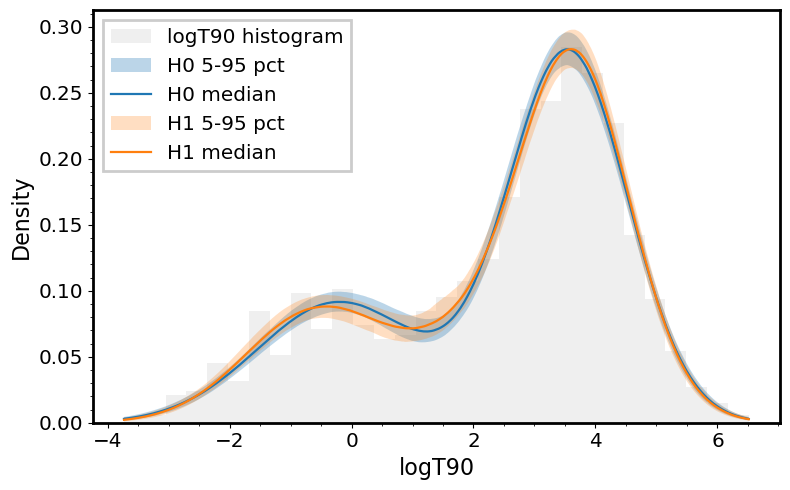

In [170]:
filename = 'T90_distribution_real'
fig3, axes3 = plot_distribution_ns(ns, logT90, filename,
                                   post_samps_H0, post_samps_H1)

## Generated data - H0

In [142]:
# Stessi utilizzati per mcmc
sample_gen = {'w': [0.3, 0.7], 'mus': [-0.5, 3.5], 'sigmas': [0.8, 1.0]}
rng        = np.random.default_rng(1234)
error      = np.median(sigma_logT90)

logT90_gen, params_gen = gen_synth_data(sample_gen, 
                                       N=logT90.shape[0],
                                       model='H0',
                                       sigma_logT90=error,
                                       rng = rng,
                                       verbose=True)


Generated synthetic mixture:
{'weights': array([0.3, 0.7]), 'mus': array([-0.5,  3.5]), 'sigmas': array([0.8, 1. ]), 'N': 1932}

Canonical params (H0) [v, mu1, delta, ln_s1, ln_s2]:
 [ 0.3        -0.5         4.         -0.22314355  0.        ]


In [143]:
%%time
LOAD = True

ns = MixtureNestedSampler(logT90_gen, error)
if LOAD == 0:
    res0, logZ0 = ns.run_once('H0', nlive=1200, dlogz=0.01, rng=rng)
    res1, logZ1 = ns.run_once('H1', nlive=1200, dlogz=0.01, rng=rng)

    # Salva risultati/res
    with open('../chains/dynesty_results_H0_genH0.pkl', 'wb') as f:
        pickle.dump(res0, f)
    with open('../chains/dynesty_results_H1_genH0.pkl', 'wb') as f:
        pickle.dump(res1, f)
else:
    with open('../chains/dynesty_results_H0_genH0.pkl', 'rb') as f:
        res0 = pickle.load(f)
    with open('../chains/dynesty_results_H1_genH0.pkl', 'rb') as f:
        res1 = pickle.load(f)
    
    logZ0 = res0.logz[-1]
    logZ1 = res1.logz[-1]

CPU times: user 24.6 ms, sys: 6.01 ms, total: 30.6 ms
Wall time: 29.5 ms


In [121]:
logZerr0 = res0.logzerr[-1]
print("H0: logZ = {:.3f} +- {:.3f}".format(logZ0, logZerr0))

logZerr1 = res1.logzerr[-1]
print("H1: logZ = {:.3f} +- {:.3f}".format(logZ1, logZerr1))

# BAYES FACTOR e probabilità a posteriori (prior model equiprobabili)
logBF = logZ1 - logZ0
# propaga errore approssimativamente
logBF_err = np.sqrt(logZerr0**2 + logZerr1**2)
post_prob_H1 = 1.0 / (1.0 + np.exp(-logBF))

print("logBF (H1 vs H0) = {:.3f} +- {:.3f}".format(logBF, logBF_err))
print("P(H1|D) (equiprob. apriori) = {:.4f}".format(post_prob_H1))

H0: logZ = -3772.029 +- 0.127
H1: logZ = -3774.665 +- 0.135
logBF (H1 vs H0) = -2.636 +- 0.185
P(H1|D) (equiprob. apriori) = 0.0669


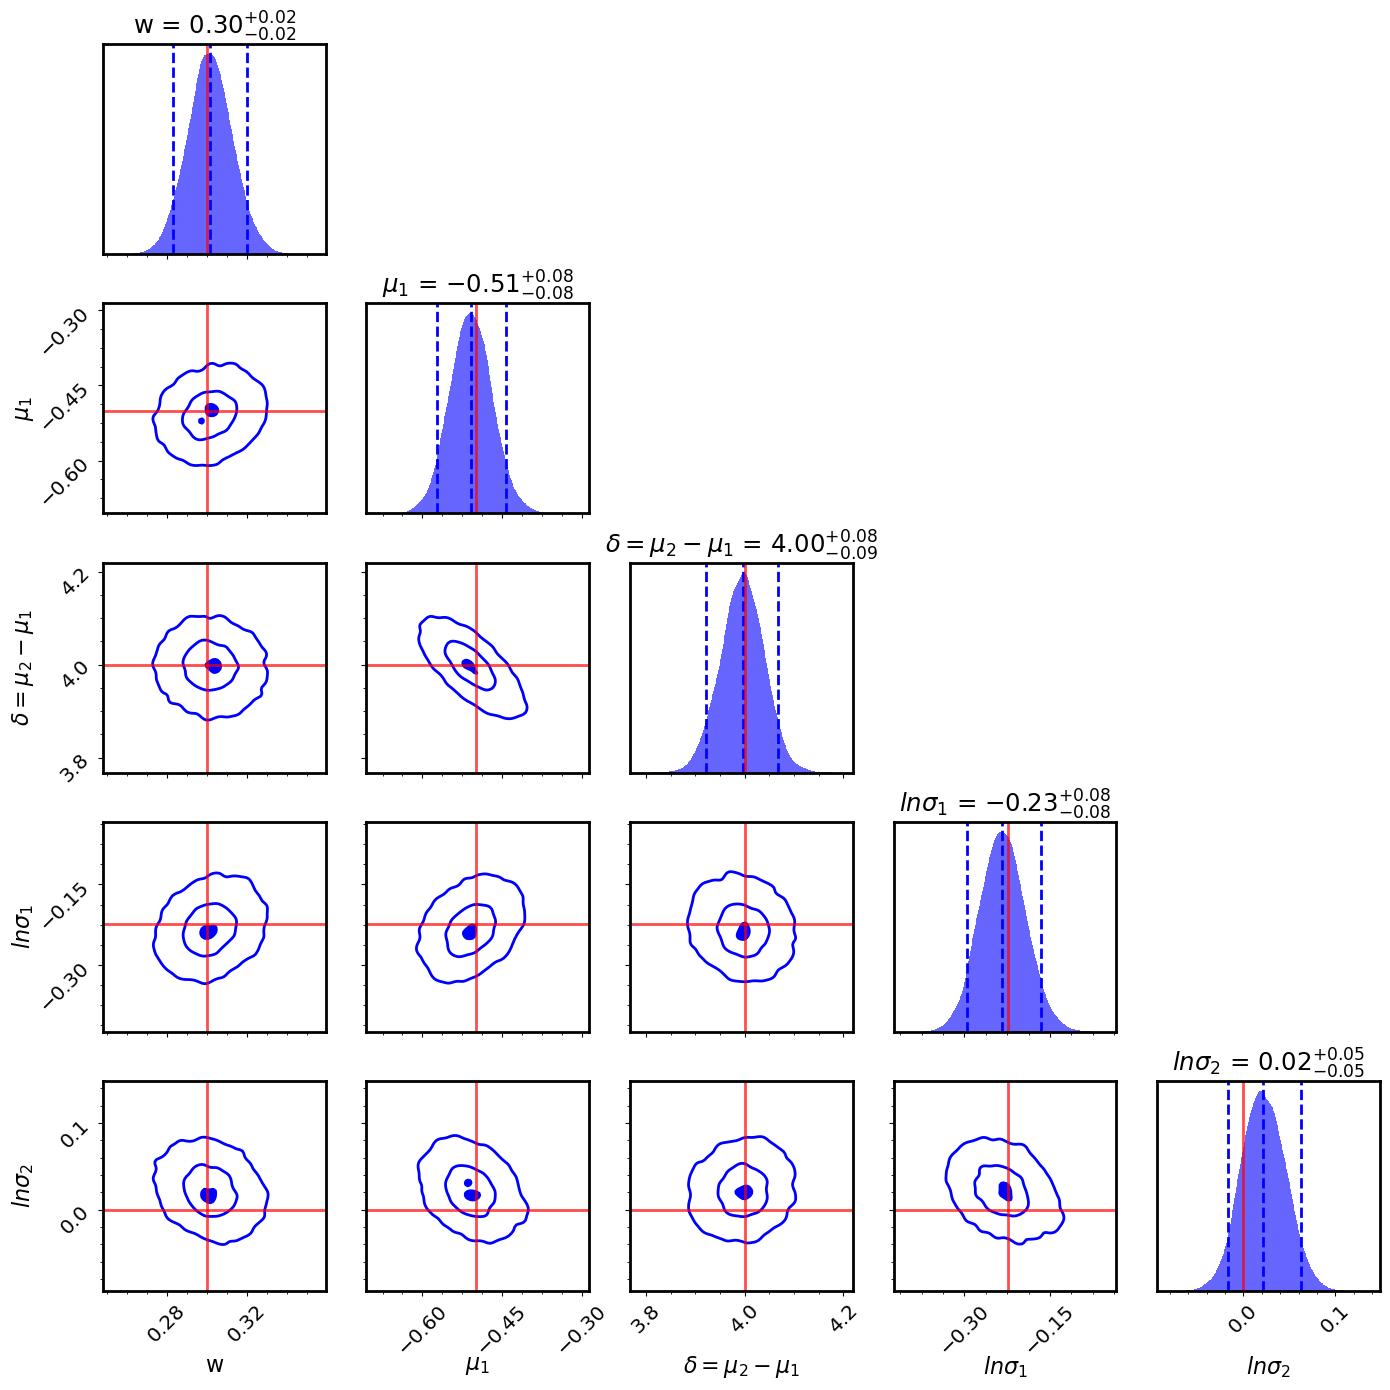

In [56]:
model     = 'H0'
filename  = f'cornerplot_ns_{model}_genH0'
fig, axes = cornerplot_ns(res0, filename, truths=params_gen, model=model, save=True)

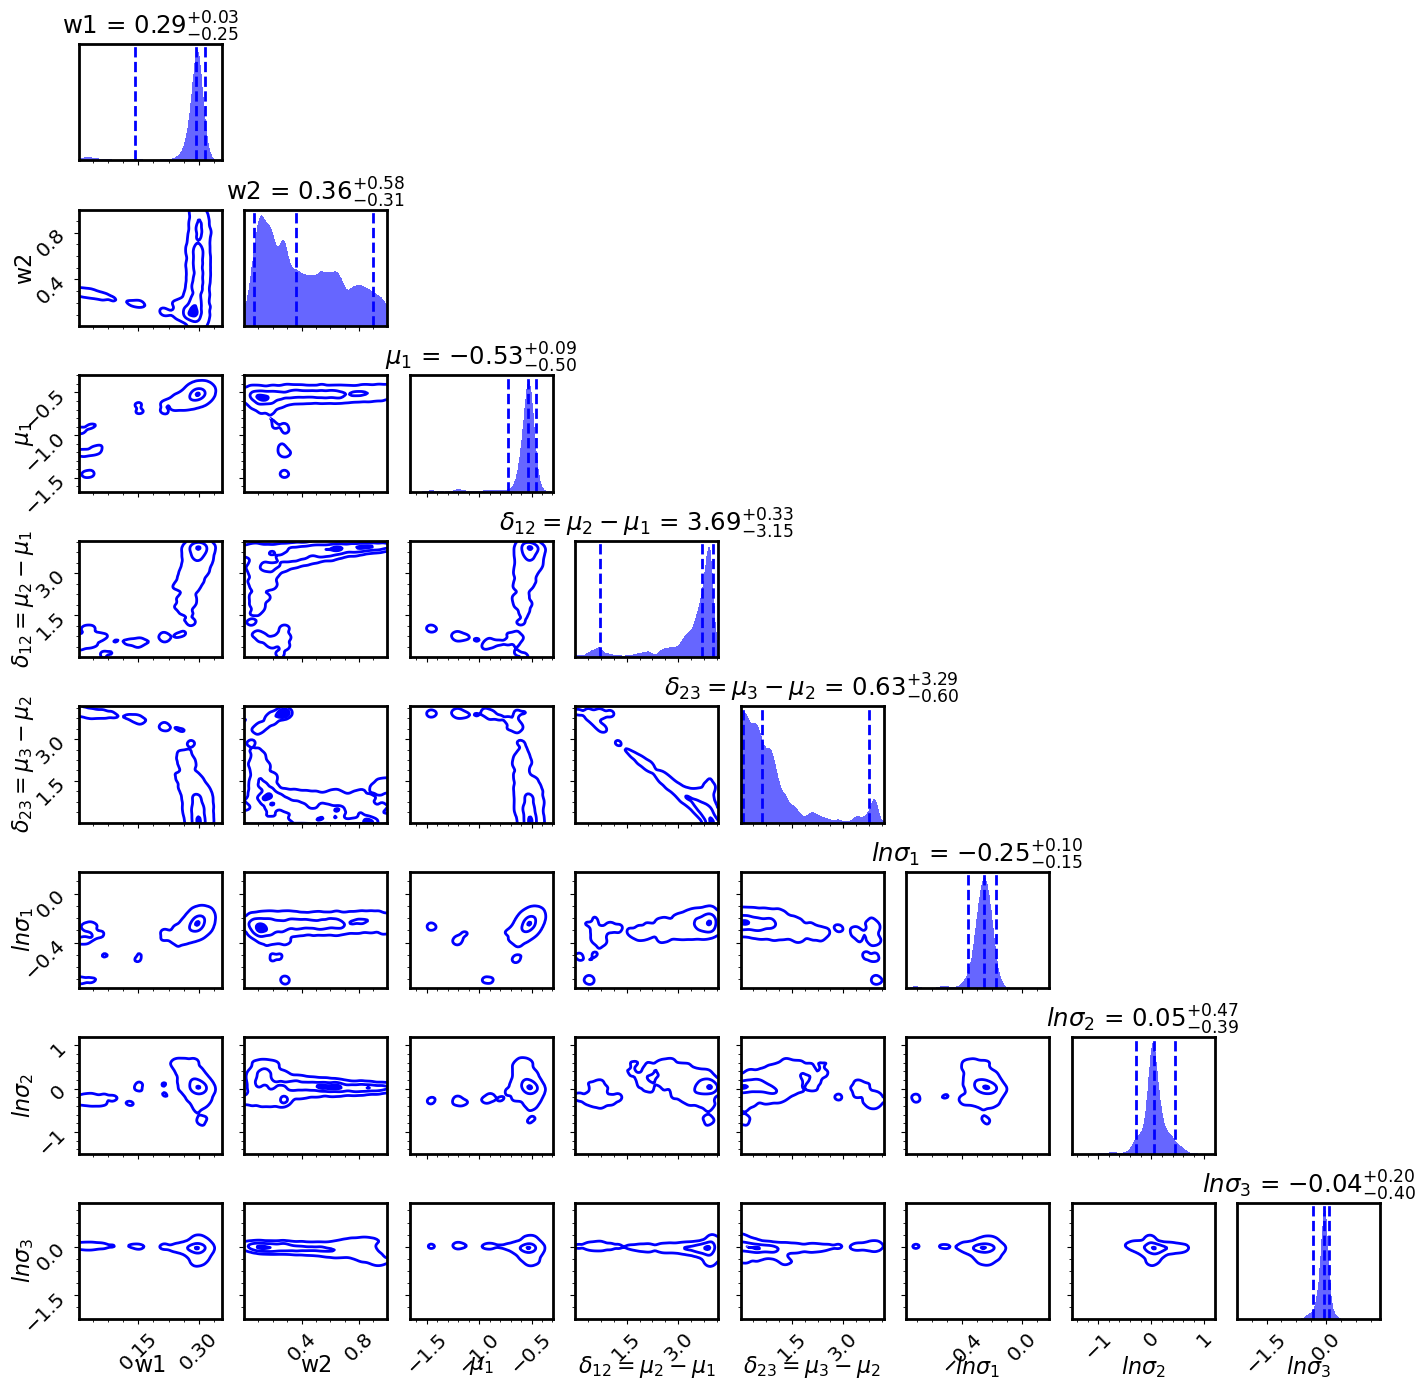

In [57]:
model = 'H1'
filename  = f'cornerplot_ns_{model}_genH0'
fig2, axes2 = cornerplot_ns(res1, filename, truths=None, model=model, save=True)

In [144]:
rng = np.random.default_rng(1234)
post_samps_H0 = ns.extract_posterior(res0, n_samples=4349, rng=rng)
df0 = ns.derived_params_propriety(post_samps_H0, model='H0')
#info = ns.params_propriety(post_samps_H0, model='H0')

post_samps_H1 = ns.extract_posterior(res1, n_samples=4349, rng=rng)
df1 = ns.derived_params_propriety(post_samps_H1, model='H1')

,param,component,mean,p0.05,p0.16,p0.5,p0.84,p0.95
0,mus,0,-0.509278,-0.572786,-0.548772,-0.509875,-0.470699,-0.443185
1,mus,1,3.486978,3.435780,3.456833,3.486554,3.518267,3.538087
2,sigs,0,0.793077,0.742746,0.761381,0.791910,0.824034,0.846488
3,sigs,1,1.023132,0.984374,0.998957,1.021949,1.047364,1.063462
4,weights,0,0.301463,0.282771,0.290117,0.301463,0.312599,0.319352
5,weights,1,0.698537,0.680648,0.687401,0.698537,0.709883,0.717229


,param,component,mean,p0.05,p0.16,p0.5,p0.84,p0.95
0,mus,0,-0.557338,-0.710318,-0.590918,-0.530114,-0.484230,-0.456042
1,mus,1,2.755604,-0.222164,2.092349,3.188156,3.424442,3.476003
2,mus,2,3.690398,3.478632,3.514479,3.608293,3.852741,4.181510
3,sigs,0,0.771826,0.700577,0.735187,0.776298,0.813671,0.836833
4,sigs,1,1.080769,0.753783,0.919168,1.048977,1.251510,1.535466
5,sigs,2,0.943135,0.710136,0.861428,0.960083,1.028431,1.092334
6,weights,0,0.280454,0.147003,0.274664,0.294416,0.307921,0.315644
7,weights,1,0.298078,0.047277,0.092038,0.273109,0.520225,0.627122
8,weights,2,0.421467,0.069800,0.178531,0.440546,0.648330,0.692469


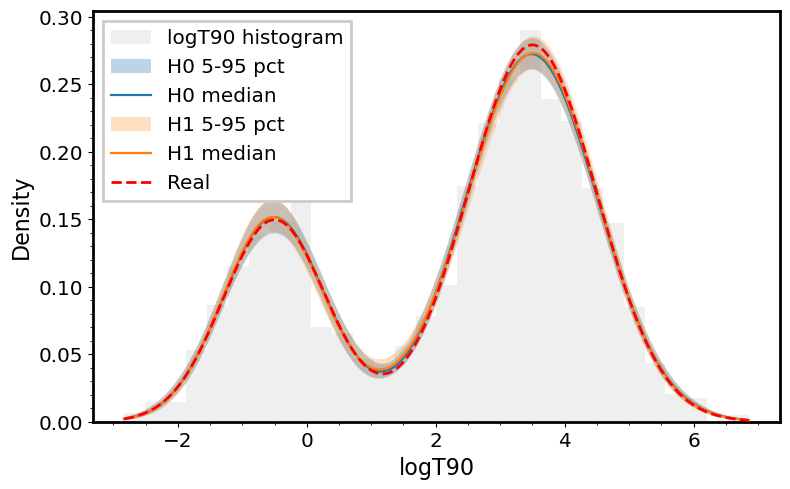

In [145]:
filename = 'T90_distribution_genH0'
fig3, axes3 = plot_distribution_ns(ns, logT90_gen, filename,
                                   post_samps_H0, post_samps_H1, sample_gen)

## Generated data - H1

In [134]:
# Stessi utilizzati per mcmc
sample_gen = {'w': [0.25, 0.15, 0.6], 'mus': [-0.5, 1.5, 3.5], 'sigmas': [0.8, 0.8, 1.0]}
rng        = np.random.default_rng(1234)
error      = np.median(sigma_logT90)

logT90_gen, params_gen = gen_synth_data(sample_gen, 
                                       N=logT90.shape[0],
                                       model='H1',
                                       sigma_logT90=error,
                                       rng = rng,
                                       verbose=True)


Generated synthetic mixture:
{'weights': array([0.25, 0.15, 0.6 ]), 'mus': array([-0.5,  1.5,  3.5]), 'sigmas': array([0.8, 0.8, 1. ]), 'N': 1932}

Canonical params (H1) [v1, v2, mu1, delta12, delta23, ln_s1, ln_s2, ln_s3]:
 [ 0.25        0.2        -0.5         2.          2.         -0.22314355
 -0.22314355  0.        ]


In [135]:
%%time
LOAD = True

ns = MixtureNestedSampler(logT90_gen, error)
if LOAD == 0:
    res0, logZ0 = ns.run_once('H0', nlive=1200, dlogz=0.01, rng=rng)
    res1, logZ1 = ns.run_once('H1', nlive=1200, dlogz=0.01, rng=rng)

    # Salva risultati/res
    with open('../chains/dynesty_results_H0_genH1.pkl', 'wb') as f:
        pickle.dump(res0, f)
    with open('../chains/dynesty_results_H1_genH1.pkl', 'wb') as f:
        pickle.dump(res1, f)
else:
    with open('../chains/dynesty_results_H0_genH1.pkl', 'rb') as f:
        res0 = pickle.load(f)
    with open('../chains/dynesty_results_H1_genH1.pkl', 'rb') as f:
        res1 = pickle.load(f)
    
    logZ0 = res0.logz[-1]
    logZ1 = res1.logz[-1]

CPU times: user 28.5 ms, sys: 5.01 ms, total: 33.5 ms
Wall time: 32.5 ms


In [136]:
logZerr0 = res0.logzerr[-1]
print("H0: logZ = {:.3f} +- {:.3f}".format(logZ0, logZerr0))

logZerr1 = res1.logzerr[-1]
print("H1: logZ = {:.3f} +- {:.3f}".format(logZ1, logZerr1))

# BAYES FACTOR e probabilità a posteriori (prior model equiprobabili)
logBF = logZ1 - logZ0
# propaga errore approssimativamente
logBF_err = np.sqrt(logZerr0**2 + logZerr1**2)
post_prob_H1 = 1.0 / (1.0 + np.exp(-logBF))

print("logBF (H1 vs H0) = {:.3f} +- {:.3f}".format(logBF, logBF_err))
print("P(H1|D) (equiprob. apriori) = {:.4f}".format(post_prob_H1))

H0: logZ = -3880.956 +- 0.123
H1: logZ = -3874.884 +- 0.137
logBF (H1 vs H0) = 6.072 +- 0.184
P(H1|D) (equiprob. apriori) = 0.9977


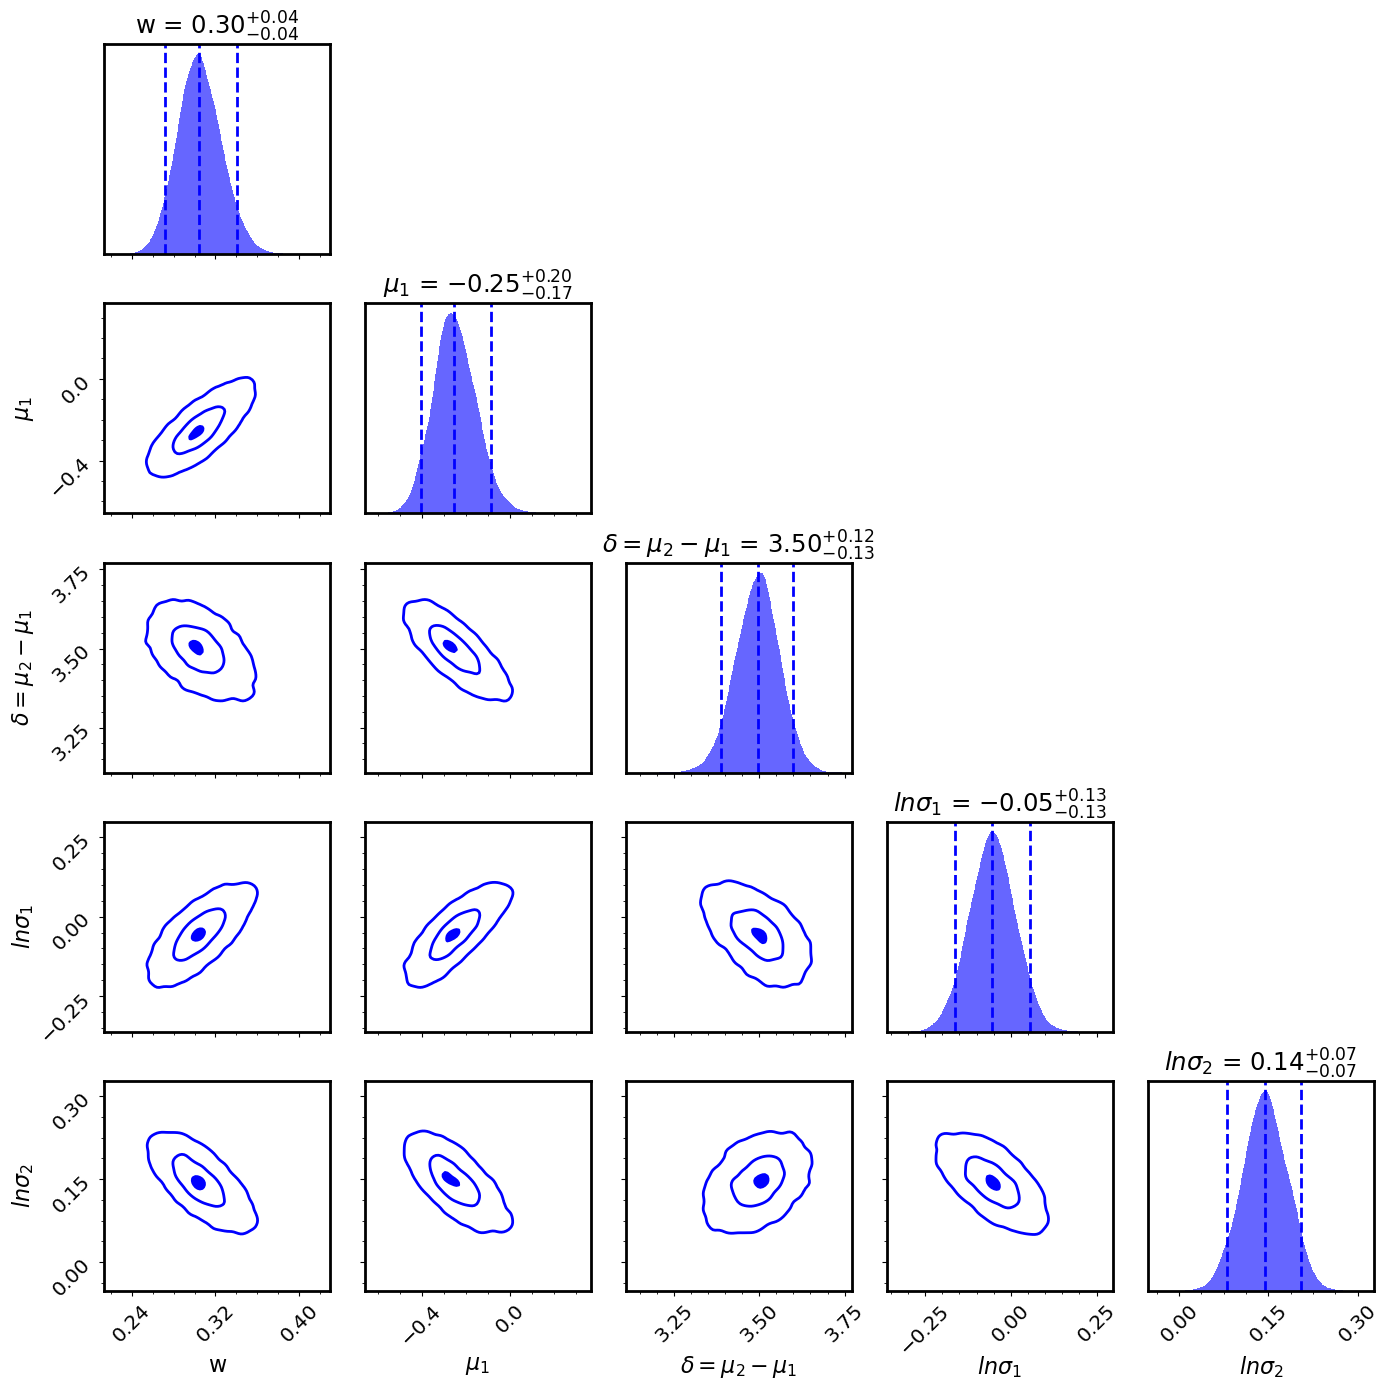

In [98]:
model     = 'H0'
filename  = f'cornerplot_ns_{model}_genH1'
fig, axes = cornerplot_ns(res0, filename, truths=None, model=model, save=True)

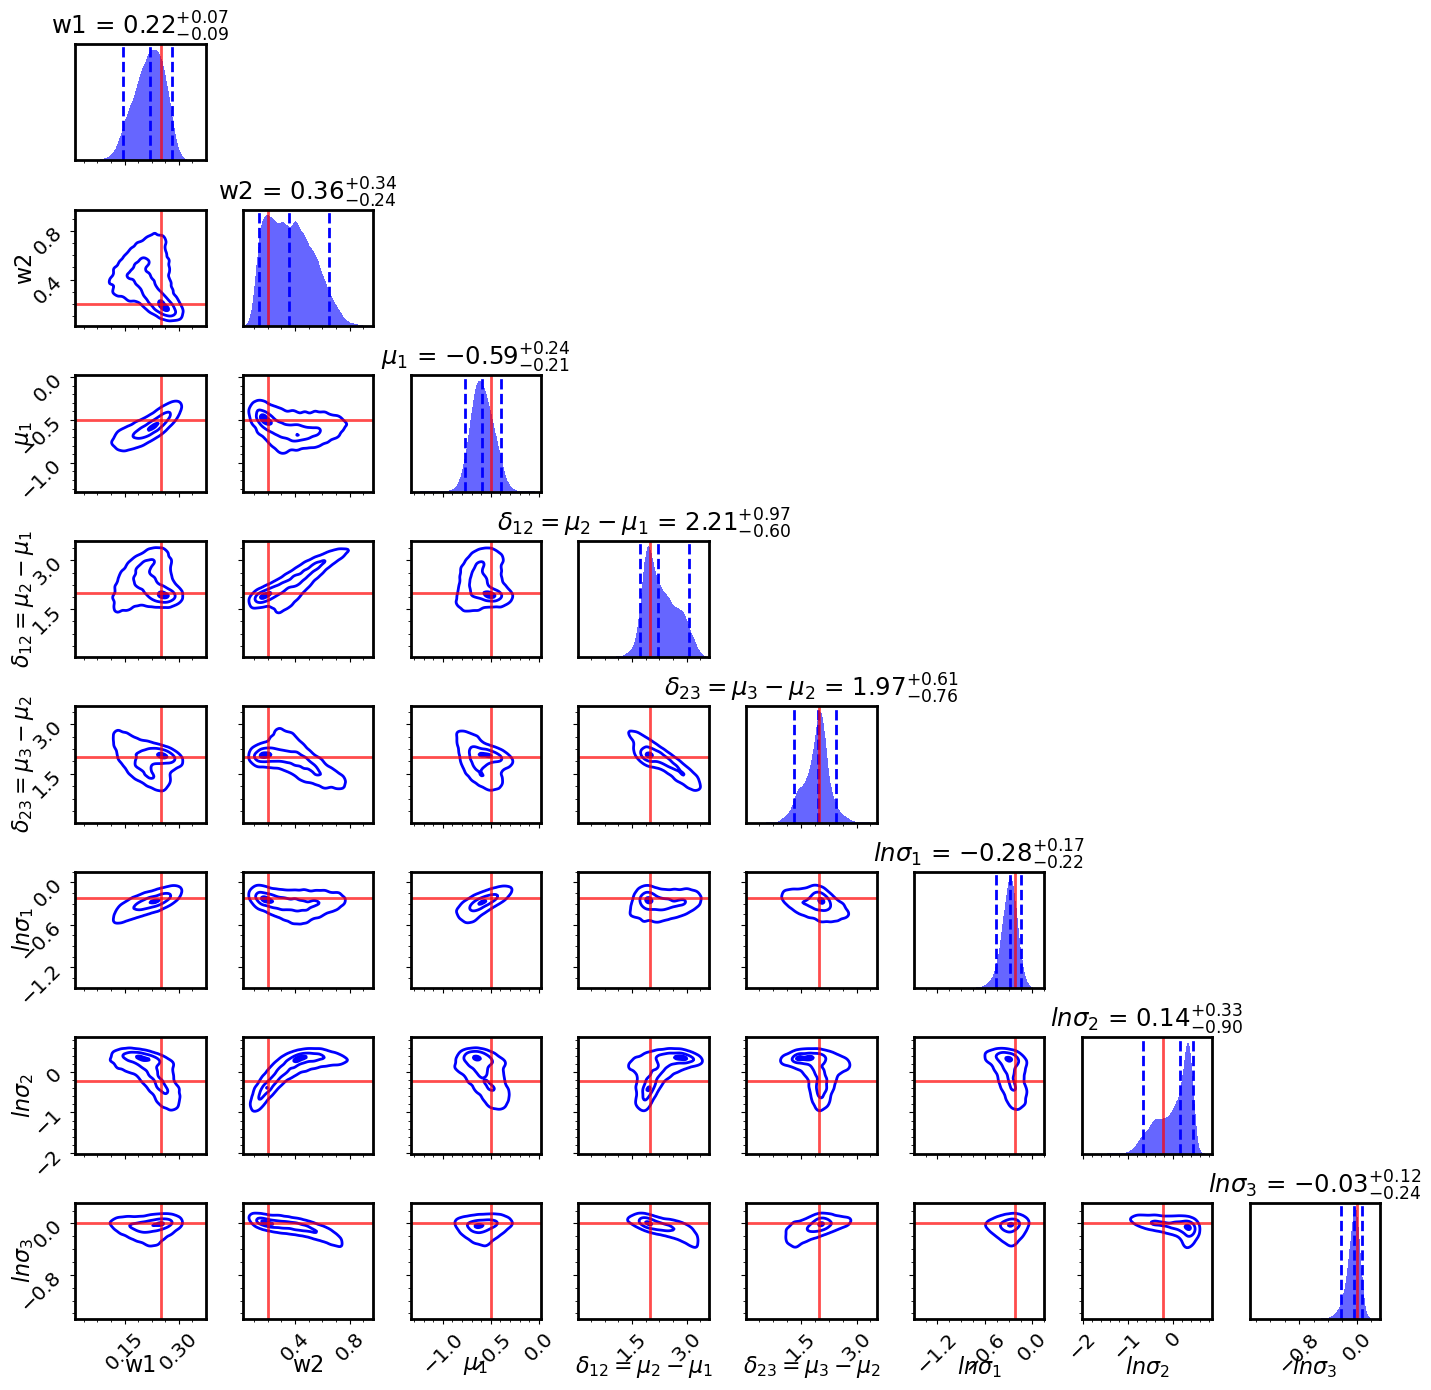

In [137]:
model = 'H1'
filename  = f'cornerplot_ns_{model}_genH1'
fig2, axes2 = cornerplot_ns(res1, filename, truths=params_gen, model=model, save=True)

In [138]:
rng = np.random.default_rng(1234)
post_samps_H0 = ns.extract_posterior(res0, n_samples=4349, rng=rng)
df0 = ns.derived_params_propriety(post_samps_H0, model='H0')
#info = ns.params_propriety(post_samps_H0, model='H0')

post_samps_H1 = ns.extract_posterior(res1, n_samples=4349, rng=rng)
df1 = ns.derived_params_propriety(post_samps_H1, model='H1')

,param,component,mean,p0.05,p0.16,p0.5,p0.84,p0.95
0,mus,0,-0.249792,-0.397821,-0.341665,-0.255155,-0.153002,-0.084218
1,mus,1,3.245939,3.151196,3.186814,3.245224,3.307324,3.348312
2,sigs,0,0.948105,0.846242,0.884872,0.946356,1.011238,1.052171
3,sigs,1,1.156943,1.087279,1.115011,1.155704,1.201401,1.228490
4,weights,0,0.304241,0.271356,0.283873,0.304006,0.324787,0.338356
5,weights,1,0.695759,0.661644,0.675213,0.695994,0.716127,0.728644


,param,component,mean,p0.05,p0.16,p0.5,p0.84,p0.95
0,mus,0,-0.583995,-0.766462,-0.697117,-0.587194,-0.464587,-0.391895
1,mus,1,1.698293,1.055221,1.299994,1.623934,2.202497,2.501737
2,mus,2,3.623544,3.399017,3.469335,3.612481,3.777536,3.887703
3,sigs,0,0.752417,0.627989,0.683576,0.754503,0.823018,0.866826
4,sigs,1,1.088527,0.515820,0.668092,1.152326,1.452505,1.554885
5,sigs,2,0.956640,0.808331,0.879755,0.966915,1.032249,1.072729
6,weights,0,0.218771,0.145202,0.174758,0.221769,0.261516,0.281466
7,weights,1,0.288450,0.098651,0.139862,0.281896,0.433671,0.510259
8,weights,2,0.492779,0.274703,0.360895,0.516611,0.610207,0.637267


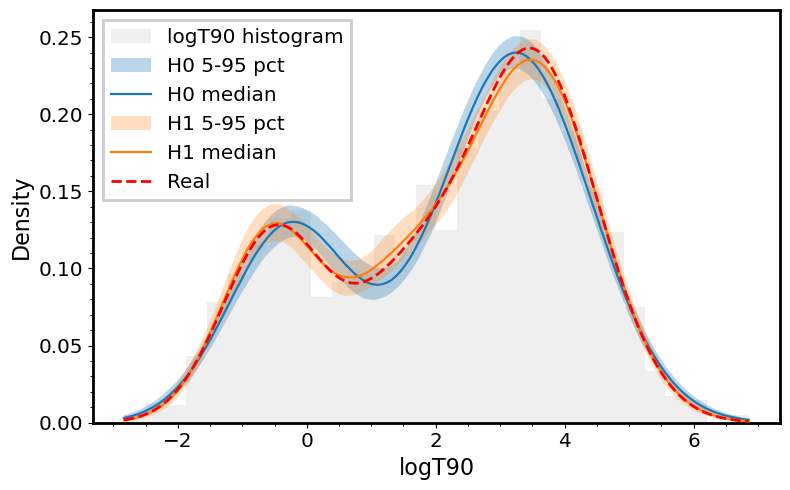

In [141]:
filename = 'T90_distribution_genH1'
fig3, axes3 = plot_distribution_ns(ns, logT90_gen, filename,
                                   post_samps_H0, post_samps_H1, sample_gen)